# Conversion Analysis

## Objective

Analyze website session conversion to understand how effectively
different acquisition sources convert website traffic into orders.

## Key Questions

1. Which acquisition sources generate the most sessions?
2. Which acquisition sources have the highest conversion rates?
3. Is conversion associated with acquisition source?
4. Is device type associated with conversion rates



## 1. Load and Prepare Data

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
#Loading data
session_conversion = pd.read_csv('../data/processed/session_conversion.csv')

In [6]:
#Inspecting the first few rows of the dataset
session_conversion.head()

,website_session_id,user_id,created_at,utm_source,utm_campaign,utm_content,device_type,is_repeat_session,converted
0,2056,1267,2012-04-02 12:49:36 UTC,NaN,NaN,NaN,desktop,1,0
1,6124,3264,2012-05-04 16:42:19 UTC,NaN,NaN,NaN,desktop,1,0
2,6165,1794,2012-05-05 06:17:59 UTC,NaN,NaN,NaN,desktop,1,0
3,6591,1902,2012-05-09 12:18:45 UTC,NaN,NaN,NaN,desktop,1,0
4,6902,3875,2012-05-11 16:13:58 UTC,NaN,NaN,NaN,desktop,1,0


In [7]:
session_conversion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   user_id             472871 non-null  int64 
 2   created_at          472871 non-null  object
 3   utm_source          389543 non-null  object
 4   utm_campaign        389543 non-null  object
 5   utm_content         389543 non-null  object
 6   device_type         472871 non-null  object
 7   is_repeat_session   472871 non-null  int64 
 8   converted           472871 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 32.5+ MB


In [12]:
#Checking the percentage of null values compared to total records
session_conversion.isnull().sum() / len(session_conversion) * 100

website_session_id     0.000000
user_id                0.000000
created_at             0.000000
utm_source            17.621719
utm_campaign          17.621719
utm_content           17.621719
device_type            0.000000
is_repeat_session      0.000000
converted              0.000000
dtype: float64

> We can see that the percentage of null values in utm_source,utm_campaign,utm_content is approx 17.6 percent which is very high hence we cannot remove the rows.

##Is conversion associated with acquisition source?

Our objective is to check whether the utm_source and conversion are independent of each other or not. In this case chi square test for independence will be best choice
> Null hypothesis: conversion and UTM_source are independent
> Alternate hypothesis: conversion and UTM_source are not independent
> Significance level: We will keep alpha at 0.05
* We will be excluding the null values from this analysis since we do not have info on their UTM source and since the data percentage of missing values is too high it would be unreliable to completely delete those rows and imputing them with mode will introduce bias in the analysis.



In [13]:
source_df = session_conversion[session_conversion['utm_source'].notna()]

In [15]:
#Importing chi2_contingency from scipy.stats
from scipy.stats import chi2_contingency

In [14]:
pd.crosstab(source_df['utm_source'], source_df['converted'])

converted,0,1
utm_source,,
bsearch,58304,4519
gsearch,294702,21333
socialbook,10342,343


<Axes: xlabel='utm_source', ylabel='count'>

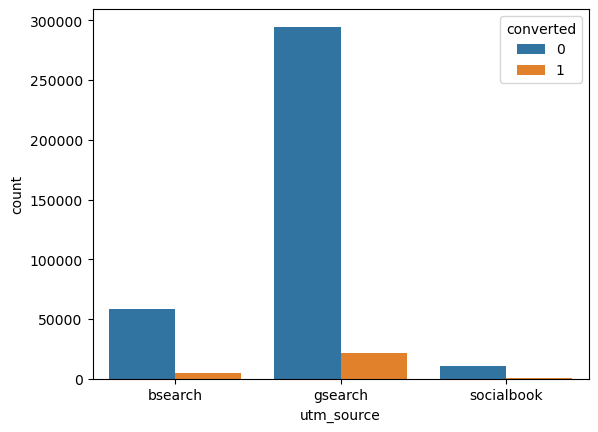

In [37]:
sns.countplot(data = source_df,x = 'utm_source',hue = 'converted')

* It seems that gsearch brings the highest traffic and also has the highest number of conversions however just by looking at the graph it is not clear if the conversion rates are same or different which will be cleared by performing the hypothesis testing.

In [16]:
chi2_contingency(pd.crosstab(source_df['utm_source'], source_df['converted']))

Chi2ContingencyResult(statistic=np.float64(232.73750897190575), pvalue=np.float64(2.8952899363727394e-51), dof=2, expected_freq=array([[ 58598.43818012,   4224.56181988],
       [294783.07960867,  21251.92039133],
       [  9966.48221121,    718.51778879]]))

In [19]:
pvalue = chi2_contingency(pd.crosstab(source_df['utm_source'], source_df['converted']))[1]

In [20]:
if pvalue < 0.05:
    print("Reject the null hypothesis: There is a significant association between utm_source and conversion.")
else:
    print("Fail to reject the null hypothesis: There is no significant association between utm_source and conversion.")

Reject the null hypothesis: There is a significant association between utm_source and conversion.


##Is conversion associated with device_type?
* Null Hypothesis: The device type and conversion is not associated
* Alternate Hypothesis: The device type and conversion is associated
* Significance level = 0.05

In [28]:
# Finding the counts to validate the countplot labellings
session_conversion.groupby(['device_type', 'converted']).count()

website_session_id  user_id  created_at  utm_source  \
device_type converted                                                        
desktop     0                      299222   299222      299222      252748   
            1                       27805    27805       27805       22703   
mobile      0                      141336   141336      141336      110600   
            1                        4508     4508        4508        3492   

                       utm_campaign  utm_content  is_repeat_session  
device_type converted                                                
desktop     0                252748       252748             299222  
            1                 22703        22703              27805  
mobile      0                110600       110600             141336  
            1                  3492         3492               4508

In [39]:
pd.crosstab(index = session_conversion['device_type'],columns = session_conversion['converted'],margins = 'All')

converted,0,1,All
device_type,,,
desktop,299222,27805,327027
mobile,141336,4508,145844
All,440558,32313,472871


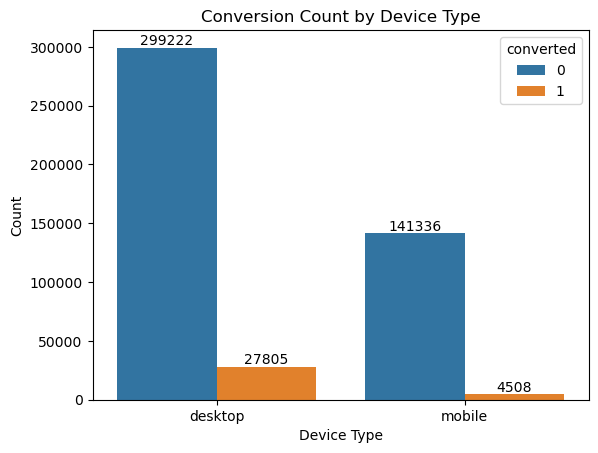

In [30]:
#Confirmed and validated the countplot labels match the actual values as well.
ax = sns.countplot(data=session_conversion, x='device_type', hue='converted')

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 5,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='black'
            )

plt.title('Conversion Count by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Count')
plt.show()

* More website sessions are generated from desktop compared to mobile.
* More orders are also placed via desktop compared to mobile however it could be due higher volume of traffic acquired hence hypothesis testing required to establish if device type and conversion is associated or not.

In [34]:
#Checked that the scenario clears the assumptions of chisquared.
pvalue2 = chi2_contingency(pd.crosstab(session_conversion['device_type'], session_conversion['converted']))[1]

In [35]:
if pvalue2 < 0.05:
    print("Reject the null hypothesis: There is a significant association between device_type and conversion.")

Reject the null hypothesis: There is a significant association between device_type and conversion.


0.0
